# Google Play Review EDA

This notebook performs an initial exploratory data analysis of the Google Play reviews collected for the prototype.

The goal is to evaluate the dataset size, structure, data quality, and potential limitations before using Google Play reviews in the downstream pipeline.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/google_play_reviews_sample.csv")

df["at"] = pd.to_datetime(df["at"], errors="coerce")
df["content"] = df["content"].fillna("")
df["text_length"] = df["content"].str.len()

df.head()

Matplotlib is building the font cache; this may take a moment.


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app_name,app_id,text_length
0,b17d6178-3f5f-4638-8c53-ec08fe2e376c,SuperSeed12,https://play-lh.googleusercontent.com/a/ACg8oc...,App crashes constantly! What happened?,3,0,9.1.60.1970,2026-06-30 16:17:40,Hi. Thanks for reporting. Have you tried a qui...,2026-06-30 16:32:04,9.1.60.1970,Spotify,com.spotify.music,38
1,8d9b55fa-8e01-4b71-8bd9-707702006f23,Armando Lozano,https://play-lh.googleusercontent.com/a/ACg8oc...,Have not explored all its' functionality. I pa...,5,0,9.1.0.1147,2026-06-30 16:10:30,NaN,NaN,9.1.0.1147,Spotify,com.spotify.music,203
2,e01836c7-8ab9-447d-82b9-e844bdccb7c6,Bart Mathias,https://play-lh.googleusercontent.com/a-/ALV-U...,it always worked fine until a day or so ago. n...,4,0,9.1.60.1970,2026-06-30 16:07:36,Hi. Thanks for reporting. Have you tried a qui...,2026-06-30 14:56:30,9.1.60.1970,Spotify,com.spotify.music,86
3,5c466440-f6b4-47a5-968b-386edf6ede7e,Neal Woelinga,https://play-lh.googleusercontent.com/a-/ALV-U...,WHY GO ANYWHERE ELSE. THEY GOT ALL YOUR ENTERT...,5,0,9.1.60.1970,2026-06-30 16:06:10,NaN,NaN,9.1.60.1970,Spotify,com.spotify.music,70
4,e9171fcc-03f0-43d5-b403-6705a1e83639,Jenny Keith Ibanita,https://play-lh.googleusercontent.com/a/ACg8oc...,The first time that I used this at first I'm c...,5,0,9.1.60.1970,2026-06-30 15:59:10,NaN,NaN,9.1.60.1970,Spotify,com.spotify.music,144


## 1. Dataset Overview

This section checks the overall size, structure, and fields of the collected Google Play review dataset.

In [2]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.columns.tolist()

Number of rows: 10000
Number of columns: 14


['reviewId',
 'userName',
 'userImage',
 'content',
 'score',
 'thumbsUpCount',
 'reviewCreatedVersion',
 'at',
 'replyContent',
 'repliedAt',
 'appVersion',
 'app_name',
 'app_id',
 'text_length']

## 2. Review Volume by App

This section checks whether the collected reviews are evenly distributed across the selected apps.

In [3]:
review_counts = df["app_name"].value_counts()
review_counts

app_name
Spotify      2000
Duolingo     2000
Instagram    2000
TikTok       2000
WhatsApp     2000
Name: count, dtype: int64

Each of the five selected apps has exactly 2,000 reviews, giving a total sample size of 10,000 reviews. This confirms that the collection script successfully retrieved the target number of reviews for each app.

## 3. Rating Distribution

This section examines the distribution of review ratings from 1 to 5 stars.

In [6]:
rating_counts = df["score"].value_counts().sort_index()
rating_counts

score
1    1825
2     402
3     459
4     833
5    6481
Name: count, dtype: int64

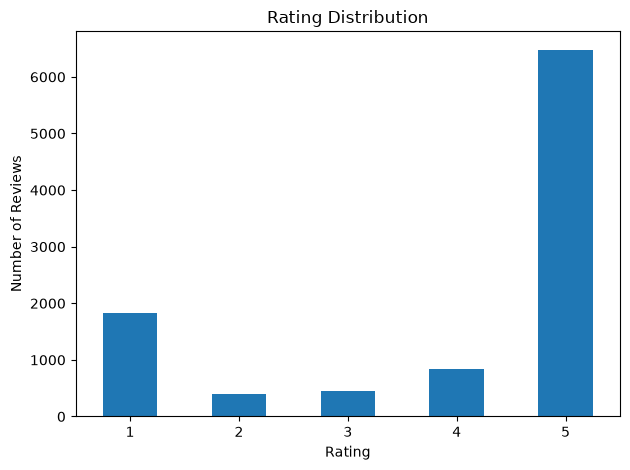

In [7]:
rating_counts.plot(kind="bar")

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
rating_by_app = pd.crosstab(df["app_name"], df["score"])
rating_by_app

score,1,2,3,4,5
app_name,,,,,
Duolingo,128,53,79,249,1491
Instagram,518,53,74,120,1235
Spotify,404,112,121,196,1167
TikTok,450,108,97,117,1228
WhatsApp,325,76,88,151,1360


The rating distribution is highly skewed toward 5-star reviews. Among the 10,000 collected reviews, 6,481 reviews are 5-star reviews, accounting for 64.81% of the sample. The next largest group is 1-star reviews, with 1,825 reviews, or 18.25% of the sample. Ratings between 2 and 4 stars are much less common.

This suggests that the sample is somewhat polarized, with many strongly positive reviews and a smaller but meaningful group of strongly negative reviews. This imbalance should be considered in downstream analysis, especially if rating is used as an outcome or label.

## 4. Review Text Length

This section examines the length of review text. Review length is useful for understanding whether the text contains enough information for downstream text analysis.

In [9]:
df["text_length"].describe()

count    10000.000000
mean        60.615800
std         95.160573
min          0.000000
25%          9.000000
50%         22.000000
75%         63.000000
max        500.000000
Name: text_length, dtype: float64

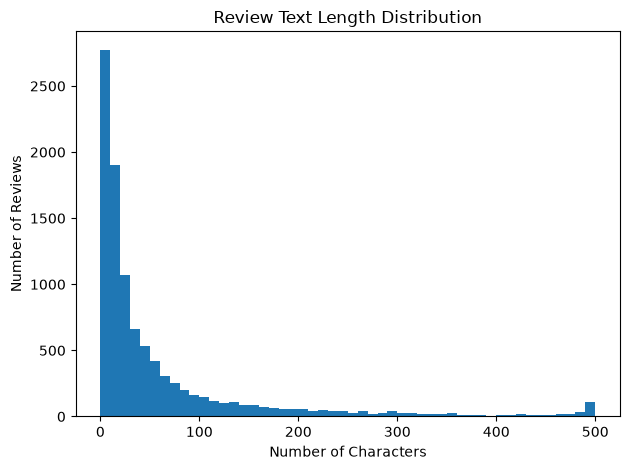

In [10]:
df["text_length"].plot(kind="hist", bins=50)

plt.title("Review Text Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

In [11]:
short_review_rate = (df["text_length"] <= 5).mean() * 100
empty_review_rate = (df["text_length"] == 0).mean() * 100

print(f"Very short reviews (<= 5 characters): {short_review_rate:.2f}%")
print(f"Empty reviews: {empty_review_rate:.2f}%")

Very short reviews (<= 5 characters): 14.25%
Empty reviews: 0.02%


The review text length distribution is strongly right-skewed. Most reviews are relatively short, with a large concentration of reviews under roughly 50 characters. At the same time, there is a long tail of longer reviews, with some reviews approaching 500 characters.

Very short or empty reviews may contain limited information for downstream text analysis. Therefore, later stages of the pipeline may need to consider filtering very short reviews or treating them separately from more detailed reviews.

## 5. Missing Fields

This section checks missing values across all fields to evaluate data completeness.

In [13]:
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts

replyContent            8105
repliedAt               8105
reviewCreatedVersion    2288
appVersion              2288
reviewId                   0
userName                   0
userImage                  0
content                    0
score                      0
thumbsUpCount              0
at                         0
app_name                   0
app_id                     0
text_length                0
dtype: int64

In [14]:
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)
missing_percent

replyContent            81.05
repliedAt               81.05
reviewCreatedVersion    22.88
appVersion              22.88
reviewId                 0.00
userName                 0.00
userImage                0.00
content                  0.00
score                    0.00
thumbsUpCount            0.00
at                       0.00
app_name                 0.00
app_id                   0.00
text_length              0.00
dtype: float64

In [15]:
missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
})

missing_summary

,missing_count,missing_percent
replyContent,8105,81.05
repliedAt,8105,81.05
reviewCreatedVersion,2288,22.88
appVersion,2288,22.88
reviewId,0,0.00
userName,0,0.00
userImage,0,0.00
content,0,0.00
score,0,0.00
thumbsUpCount,0,0.00


Most key fields are complete in the processed dataset, including review ID, username, review text, rating, thumbs-up count, timestamp, app name, and app ID. The main missing fields are developer reply fields and app version fields.

Developer reply fields are missing for 8,105 reviews, or 81.05% of the dataset. This is expected because most user reviews do not receive developer replies. App version information is missing for 2,288 reviews, or 22.88% of the dataset, which suggests that version-level analysis may be possible but incomplete.

## 6. Duplicate Records

This section checks whether the dataset contains duplicate reviews.

In [16]:
# Check exact duplicate rows
exact_duplicate_count = df.duplicated().sum()

# Check duplicate review IDs
duplicate_review_id_count = df["reviewId"].duplicated().sum()

# Check duplicate content within the same app
duplicate_app_content_count = df.duplicated(subset=["app_id", "content"]).sum()

print(f"Exact duplicate rows: {exact_duplicate_count}")
print(f"Duplicate review IDs: {duplicate_review_id_count}")
print(f"Duplicate app-content pairs: {duplicate_app_content_count}")

Exact duplicate rows: 0
Duplicate review IDs: 0
Duplicate app-content pairs: 1431


There are no exact duplicate rows and no duplicated review IDs in the dataset. This suggests that the collection process did not repeatedly retrieve the same review records, and `reviewId` can be used as the unique identifier for reviews.

There are 1,431 duplicate app-content pairs. However, this does not necessarily indicate duplicate records because different users may leave the same review text for the same app, especially for short comments such as "good", "great".

## 7. Timestamp Coverage

This section examines the time range covered by the collected reviews.

In [17]:
print("Earliest review timestamp:", df["at"].min())
print("Latest review timestamp:", df["at"].max())

Earliest review timestamp: 2026-06-27 19:44:11
Latest review timestamp: 2026-06-30 16:19:19


In [18]:
timestamp_by_app = df.groupby("app_name")["at"].agg(["min", "max"])
timestamp_by_app

,min,max
app_name,,
Duolingo,2026-06-29 08:33:36,2026-06-30 16:18:55
Instagram,2026-06-30 00:17:54,2026-06-30 16:15:15
Spotify,2026-06-28 04:55:24,2026-06-30 16:17:40
TikTok,2026-06-27 19:44:11,2026-06-30 16:18:40
WhatsApp,2026-06-30 04:04:57,2026-06-30 16:19:19


The collected newest-review sample covers a short and recent time window.

## 8. App Version Availability

This section checks how often app version information is available in the collected reviews.

In [21]:
version_missing_count = df["reviewCreatedVersion"].isna().sum()
version_available_count = df["reviewCreatedVersion"].notna().sum()
version_missing_percent = df["reviewCreatedVersion"].isna().mean() * 100
version_available_percent = df["reviewCreatedVersion"].notna().mean() * 100

print(f"App version available: {version_available_count} ({version_available_percent:.2f}%)")
print(f"App version missing: {version_missing_count} ({version_missing_percent:.2f}%)")

App version available: 7712 (77.12%)
App version missing: 2288 (22.88%)


In [22]:
version_availability_by_app = df.groupby("app_name")["reviewCreatedVersion"].apply(
    lambda x: pd.Series({
        "available_count": x.notna().sum(),
        "missing_count": x.isna().sum(),
        "available_percent": x.notna().mean() * 100,
        "missing_percent": x.isna().mean() * 100
    })
).unstack()

version_availability_by_app

,available_count,missing_count,available_percent,missing_percent
app_name,,,,
Duolingo,1871.0,129.0,93.55,6.45
Instagram,1316.0,684.0,65.80,34.20
Spotify,1656.0,344.0,82.80,17.20
TikTok,1236.0,764.0,61.80,38.20
WhatsApp,1633.0,367.0,81.65,18.35


App version availability differs by app. Duolingo has the highest availability at 93.55%, while TikTok and Instagram have the highest missing rates at 38.20% and 34.20%. This suggests that app version information can be useful, but it should be treated as partially available rather than complete.

## 9. Language and Low-Quality Review Checks

This section performs simple rule-based checks for potentially low-information reviews, such as empty reviews, very short reviews, and reviews without English letters.

In [24]:
df["content_clean"] = df["content"].fillna("").astype(str).str.strip()
df["is_empty"] = df["content_clean"].eq("")
df["is_very_short"] = df["content_clean"].str.len() <= 5
df["has_no_english_letters"] = ~df["content_clean"].str.contains(r"[A-Za-z]", regex=True)

In [25]:
quality_summary = pd.DataFrame({
    "count": [
        df["is_empty"].sum(),
        df["is_very_short"].sum(),
        df["has_no_english_letters"].sum()
    ],
    "percent": [
        df["is_empty"].mean() * 100,
        df["is_very_short"].mean() * 100,
        df["has_no_english_letters"].mean() * 100
    ]
}, index=[
    "Empty reviews",
    "Very short reviews (<= 5 characters)",
    "Reviews with no English letters"
])

quality_summary

,count,percent
Empty reviews,2,0.02
Very short reviews (<= 5 characters),1425,14.25
Reviews with no English letters,469,4.69


In [28]:
df[df["is_very_short"]][["app_name", "score", "content", "at"]].head(10)

,app_name,score,content,at
5,Spotify,5,عالیه,2026-06-30 15:52:53
10,Spotify,5,great,2026-06-30 15:48:29
12,Spotify,5,good,2026-06-30 15:41:59
35,Spotify,5,laka,2026-06-30 14:42:38
54,Spotify,5,nice,2026-06-30 14:01:42
56,Spotify,5,good,2026-06-30 13:53:53
71,Spotify,5,ممتاز,2026-06-30 13:28:49
79,Spotify,5,😘👌🏾,2026-06-30 13:20:22
111,Spotify,5,👍,2026-06-30 12:19:36
124,Spotify,5,great,2026-06-30 12:00:56


In [29]:
df[df["has_no_english_letters"]][["app_name", "score", "content", "at"]].head(10)

,app_name,score,content,at
5,Spotify,5,عالیه,2026-06-30 15:52:53
9,Spotify,1,еее писна ми да плащам. пускайте го безплатно ...,2026-06-30 15:49:09
71,Spotify,5,ممتاز,2026-06-30 13:28:49
79,Spotify,5,😘👌🏾,2026-06-30 13:20:22
111,Spotify,5,👍,2026-06-30 12:19:36
129,Spotify,5,✅✅✅✅✅,2026-06-30 11:50:40
152,Spotify,5,😄😄😄,2026-06-30 11:32:16
235,Spotify,5,,2026-06-30 09:28:08
304,Spotify,5,(: (:,2026-06-30 08:11:20
350,Spotify,5,🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥,2026-06-30 06:51:31


The rule-based quality checks suggest that empty reviews are rare: only 2 reviews, or 0.02% of the dataset, are empty. However, 1,425 reviews, or 14.25%, are very short reviews with 5 or fewer characters. These reviews may include low-information comments such as "good", "ok", or emoji-only responses.

In addition, 469 reviews, or 4.69%, contain no English letters. This may include non-English reviews, emoji-only reviews, or reviews written in non-Latin scripts. Since this is only a simple rule-based check, it should not be interpreted as formal language detection.

The review text is mostly usable, but downstream text analysis may need filtering or separate handling for very short reviews and reviews with no English letters.

## 10. Limitations

This sample was collected using the newest sorting option, so the timestamp coverage is concentrated within a short recent time window, from June 27, 2026 to June 30, 2026. This makes the dataset useful for evaluating recent review data quality, but it does not represent long-term historical review patterns.

The language and low-quality review checks are preliminary and rule-based. A later version of the pipeline may need formal language detection, more systematic text cleaning, and filtering or separate handling of very short or low-information reviews.

Overall, Google Play appears feasible for the initial prototype because it provides accessible, structured, and repeatable review data at the scale needed for basic analysis.